<a href="https://colab.research.google.com/github/quizo666/OPP2024/blob/main/Final_Project_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas

In [ ]:
import pandas as pd

In [ ]:
chess = pd.read_csv('/content/games.csv')

In [ ]:
chess.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  object 
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  object 
 6   winner          20058 non-null  object 
 7   increment_code  20058 non-null  object 
 8   white_id        20058 non-null  object 
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  object 
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  object 
 13  opening_eco     20058 non-null  object 
 14  opening_name    20058 non-null  object 
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(9)
memory usage: 2.3+ MB


**Источник**

Датасет "Chess Game Dataset (Lichess)" взят с сайта Kaggle.com
Датасет содержит в себе исчерпывающую информацию более чем о 20к+ играх на сайте Lichess. В датасете описываются важнейшие статистические данные: тип фигур, последовательность ходов, время игры, id партии, исход и т.д.



**Данные о датасете**

*  **id**  -- кодовый номер партии на сайте
*  **rated**   -- игра на рейтинг или нет
*  **created_at**  -- время создания игры  
*  **last_move_at**   -- время завершения игры
*  **turns**        -- количество ходов  
*  **victory_status**   -- исход игры
*  **winner**    -- сторона-победитель     
*  **increment_code** -- временной режим игры
*  **white_id**        -- серийный номер игрок белыми фигурами
*  **white_rating**    -- рейтинг игрока белыми фигурами
*  **black_id**      --  серийный номер игрок черными фигурами
*  **black_rating**     -- рейтинг игрока черными фигурами
*  **moves**        -- последовательность ходов
*  **opening_eco**     -- кодовое значение дебюта (название дебюта и первые пять ходов, зашифрованные особым кодом)
*  **opening_name**   -- название дебюта
*  **opening_ply**  -- первые пять ходов дебюта

**Тип данных**
*  **id**  -- object (строчное значение)
*  **rated**   -- bool (логический, где есть либо True, либо False)
*  **created_at**  --   float64 (с плавающей точкой)
*  **last_move_at**   --  float64 (с плавающей точкой)
*  **turns**        --   int64 (целое число, ходов не может быть дробное количество)
*  **victory_status**   -- object (строчное значение)
*  **winner**    --   object (строчное значение)   
*  **increment_code** -- object (строчное значение)
*  **white_id**        -- object (строчное значение)
*  **white_rating**    --  int64 (рейтинг на сайте не может быть дробным)
*  **black_id**      --  object (строчное значение)
*  **black_rating**     -- int64 (рейтинг на сайте не может быть дробным)
*  **moves**        -- object (строчное значение)
*  **opening_eco**     -- object (строчное значение)
*  **opening_name**   -- object (строчное значение)
*  **opening_ply**  -- int64


In [ ]:
chess.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


## **Задание 2: Фильтрация**
Отфильтруем игры по следующим условиям:

- Игра должна быть рейтинговой (столбец rated).
- Количество ходов должно быть больше 40 (столбец turns).
- Победителем должен быть игрок, играющий белыми (столбец winner).
- Рейтинг белых игроков должен быть больше 2000 (столбец white_rating).
- Игра должна завершиться матом (столбец victory_status).

In [ ]:


filtered_games = chess[
    (chess['rated'] == True) &
    (chess['turns'] > 40) &
    (chess['winner'] == 'white') &
    (chess['white_rating'] > 2000) &
    (chess['victory_status'] == 'mate')
]

print(f"Количество отфильтрованных игр: {len(filtered_games)}")

white_wins_percentage = (len(filtered_games) / len(chess)) * 100
print(f"Процент игр, где белые с рейтингом > 2000 выиграли матом и сделали более 40 ходов: {white_wins_percentage:.2f}%")

Количество отфильтрованных игр: 134
Процент игр, где белые с рейтингом > 2000 выиграли матом и сделали более 40 ходов: 0.67%


Text(0, 0.5, 'Частота')

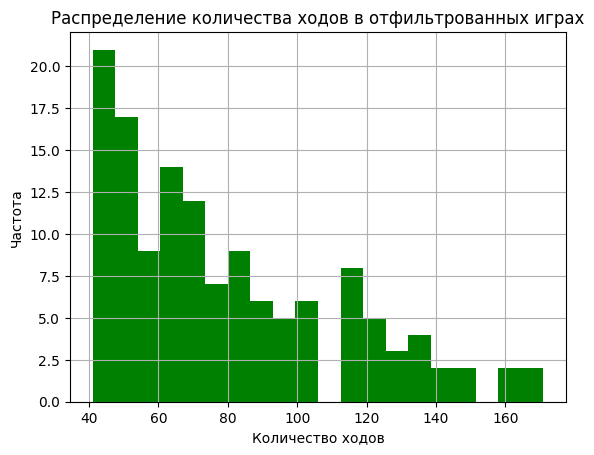

In [ ]:
ax = filtered_games['turns'].hist(bins=20, color='green')
ax.set_title('Распределение количества ходов в отфильтрованных играх')
ax.set_xlabel('Количество ходов')
ax.set_ylabel('Частота')



**Распределение**:

Наибольшее количество игр завершается в диапазоне 40-60 ходов. Это типично для профессиональных игроков, поскольку партии с более чем 40 ходами указывают на глубокие стратегические игры.
После 60 ходов частота снижается, что указывает на то, что длинные игры (более 100 ходов) встречаются реже.

**Длинные игры**:

Игры, продолжающиеся более 120 ходов, значительно реже встречаются среди профессиональных игроков, что может свидетельствовать о том, что такие партии требуют исключительных навыков и терпения, либо редкие ситуации, требующие длительных маневров.

**Заключение**:

Большинство партий среди профессионалов заканчиваются относительно быстро (40-60 ходов), что говорит о высоком уровне мастерства и умении эффективно завершать игры.

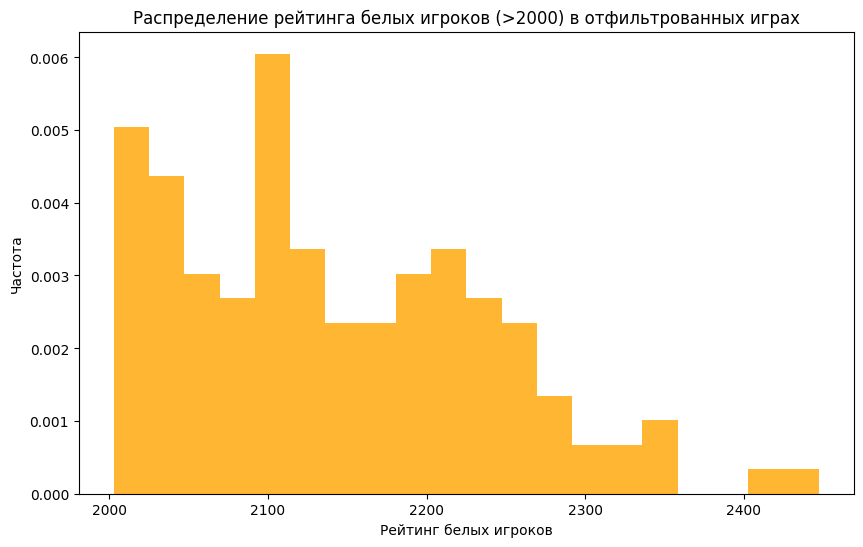

In [ ]:
# Гистограмма распределения рейтинга белых игроков
ax = filtered_games['white_rating'].plot.hist(bins=20, figsize=(10, 6), color='orange', density=True, alpha=0.8, title='Распределение рейтинга белых игроков (>2000) в отфильтрованных играх', xlabel='Рейтинг белых игроков', ylabel='Частота')


**Распределение рейтингов**:

Большая часть игроков имеет рейтинг в диапазоне от 2000 до 2200. В этом диапазоне наблюдается пик частоты, особенно в районе 2050–2150, что говорит о том, что большинство профессиональных игроков, участвующих в отфильтрованных играх, имеют средний профессиональный уровень.
Частота уменьшается по мере увеличения рейтинга. Игроков с рейтингом выше 2300 значительно меньше, и они встречаются реже.

**Редкость высоких рейтингов**:

Игроки с рейтингом выше 2300, хотя и участвуют в некоторых партиях, представлены гораздо меньшей частотой, что может свидетельствовать о том, что чем выше рейтинг, тем реже встречаются такие игроки среди белых победителей с завершением игры матом.

**Заключение**:

Большинство игр выиграно белыми игроками с рейтингом в диапазоне 2000–2200, что может говорить о том, что этот диапазон рейтинга характерен для частых побед. Игроки с более высоким рейтингом, хотя и встречаются, играют реже, что может быть связано с уменьшением числа игроков с таким рейтингом в базе данных или с особенностями отбора партий.

<Axes: title={'center': 'Распределение побед среди всех игроков'}, ylabel='count'>

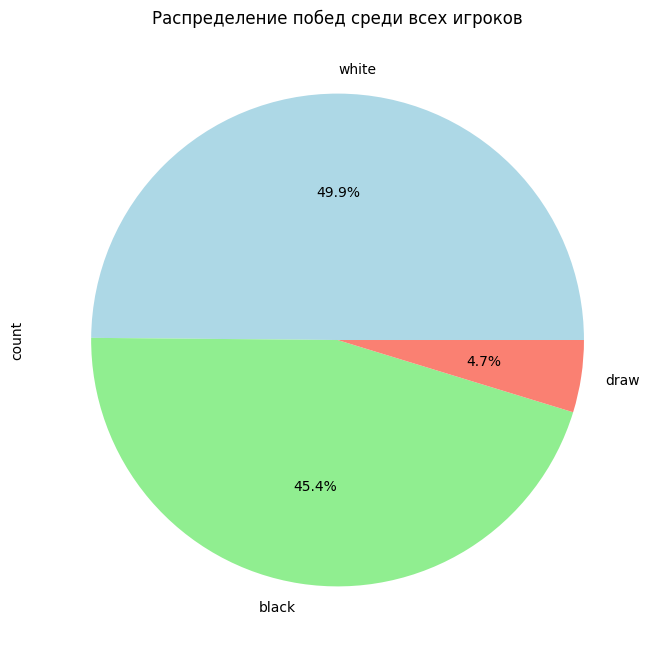

In [ ]:
# Круговая диаграмма побед
winner_counts = chess['winner'].value_counts()
winner_counts.plot.pie(figsize=(8, 8), autopct='%1.1f%%', colors=['lightblue', 'lightgreen', 'salmon'], title='Распределение побед среди всех игроков')

**Победы белых (49.9%)**:

Почти половина всех игр заканчивается победой белых. Это вполне ожидаемо, так как белые делают первый ход, что дает им начальное преимущество.

**Победы черных (45.4%)**:

Черные побеждают в 45.4% случаев, что демонстрирует высокий уровень уравновешенности между сторонами. Черные игроки способны эффективно отвечать на инициативу белых, что характерно для высококвалифицированных игроков.

**Ничьи (4.7%)**:

Низкий процент ничьих говорит о том, что большинство партий заканчивается победой одной из сторон. Это может свидетельствовать о том, что профессиональные игроки редко доводят партии до ничьей, стремясь к победе.


**Задание 3: Сортировка**

In [ ]:
sorted_games = chess.sort_values(by= ['black_rating', 'turns', 'victory_status'], ascending = [False, True, True]) #Здесь сортировка по рейтингу, чтобы смотреть, какой самый частый исход игры (мат, игрок сдался, закончилось время) у высокоуровневых игроков
sorted_games.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
4473,rAO6oybn,False,1.480830e+12,1.480830e+12,1,outoftime,white,5+5,ranchowangdu,1500,justicebot,2723,e4,B00,King's Pawn,1
12614,uH1mpzvB,False,1.500726e+12,1.500726e+12,17,resign,black,10+25,koryakinrus,1715,lance5500,2621,e4 c5 Nf3 d6 d4 Nf6 e5 dxe5 dxe5 Qxd1+ Kxd1 Ng...,B50,Sicilian Defense: Modern Variations | Anti-Qx...,6
12680,0C3HN9UQ,False,1.496967e+12,1.496967e+12,22,resign,black,15+0,raulelbueno,1384,lance5500,2621,f3 e5 g3 d5 Bg2 Nf6 b3 Be7 Na3 O-O Bb2 Nc6 Bc3...,A00,Gedult's Opening,1
5373,zkk33R0Z,False,1.496890e+12,1.496890e+12,40,mate,black,15+0,burks,1016,lance5500,2621,Nc3 c5 Nf3 Nc6 Nb5 Nf6 c4 g6 Ng5 Bg7 d3 O-O Bf...,A00,Van Geet Opening,1
5374,5gtNuMhB,False,1.496880e+12,1.496880e+12,48,mate,black,10+0,burks,1016,lance5500,2621,Nf3 Nf6 d4 g6 Bg5 Bg7 Nc3 d5 Qd3 Bf5 Qb5+ Nc6 ...,A48,Torre Attack,5


**Задание 4: Частотные таблицы**

In [ ]:
victory_frequency = chess.groupby('victory_status').size()

victory_frequency

,0
victory_status,
draw,906
mate,6325
outoftime,1680
resign,11147


**Результаты анализа**:

После фильтрации и преобразования ее результатов в частотную таблицу становится ясно, что среди профессиональных игроков (игроков, имеющих 2000 и более ЭЛО), игры чаще всего заканчиваются сдачей одной из сторон (55 процентов всех игр), затем следует мат (31 процент всех игр), посел мата идет окончание времени (8 процентов игр), а замыкает эту таблицу ничья (около 3 проецнтов). Что нам может сказать такая статистика? Профессиональные игроки часто стремятся сыграть как можно больше игр, так как чаще всего побеждает тот, кто за определенный промежуток времени наберет больше всего турнирных очков. Именно поэтому, если профессиональный игрок понимает, что проиграет, то он не затягивает игру до очевидного мата и заканчивает ее раньше, сдаваясь своему оппоненту. Это грамотная тактика, которая позволяет сохранить драгоценные силы и время на подготовку к более важным матчам. Однако, если игрок не сдается, то игра чаще заканчивается матом, чем истекшим временем. Это свидетельствует о том, что профессионалы практически не допускают ошибок в эндшпиле, не упуская возможность "заматовать" оппонента, что разительно отличает их от игроков более низкого уровня. Низкий процент ничьих говорит о том, что для профессионалов максимально невыгодно играть в ничью - за нее также как за поражение отбирают очки (правда, не так много, как за проигрыш), для таких игроков ничья -- потраченные ценные ресурсы: время на подготовку и интеллектуальные силы, поэтому каждый играет на исключительно на победу

In [ ]:
color_frequency = chess.groupby('winner').size()
color_frequency

,0
winner,
black,9107
draw,950
white,10001


**Результаты анализа**:

После очередной фильтрации по цветам фигур, мы видим, что процент побед белыми фигурами незначительно опережает процент побед черными (около 3 процентов разницы). Это говорит о том, что профессиональные игроки прекрасно владеют обеими цветами фигур, пускай белые признаны стороной с преимуществом из-за того, что те делают первый ход, соответственно навызявая свою игру оппоненту с черными фигурами. Однако также это показывает, что профессионалы умеют развивать преимущество белой стороны, в отличии от иигроков рейтингом ниже.

In [ ]:
opening_frequency = chess.groupby('opening_name').size()
opening_frequency.sort_values(ascending = False)

,0
opening_name,
Van't Kruijs Opening,368
Sicilian Defense,358
Sicilian Defense: Bowdler Attack,296
Scotch Game,271
French Defense: Knight Variation,271
...,...
Queen's Gambit Accepted: Bogoljubov Defense,1
Queen's Gambit Accepted: Central Variation | Rubinstein Defense,1
Queen's Gambit Accepted: Central Variation | Rubinstein Defense | Yefimov Gambit,1


**Результаты анализа**:

Мы решили также проанализировать, какие дебюты используют выоскорейтинговые игроки чаще всего. Так, самым используемым стал дебют Ван Круйса, который начинается с ходов е2-е3. Этот дебют хорош тем, что позволяет с самого начала выгодно развить ключевые и самые сильные фигуры за белых -- ферзя и белоклеточного слона, чтобы быстро начать угрожать матом королю черных. Присущ игрокам с атакующим стилем, любителям быстро завершать игры. Опасен тем, что легко поймать на контратаке. Далее (на 10 игр меньше лидера) идет легендарная сицилийская защита. Все просто -- это самый популярный дебют за черных. Это очень универсальный и динамичный дебют, который может позволить перехватить инициативу. За ним следует лишь более агрессивная разновидность: Вариант Боудлера. Поровну игр имеют Шотландская партия и французская защита. Почему так? Французская защита: вариант двух коней является самым популярным и самым правильнным ответом на знаменитый дебют Ван Круйса, а так как мы рассматриваем игры профессионалов, то законмероно, что они знают, как правильно использовать францусзкую защиту против этого дебюта. Шотландская же партия -- еще один довольно распространенный вариант защиты от агрессивныз дебютов за белых вроде дебюта Ван Круйса. "Шотландка" хороша тем, насколько сложные и интересные позиции она позволяет занять, и насколько может усложнить принятие решений стороне атаки.

**Задание 6: Частотные таблицы по отсортированным данным**

In [ ]:
def filter_dur(duration): # Функцией создаем 3 условия определения длительности игры
    if duration < 30:
        return 'short'
    elif duration >= 90:
        return 'long'
    else:
        return 'medium'

In [ ]:
chess['game_duration'] = chess['turns'].apply(filter_dur) #создали столбец с новой категорией game_duration
chess

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply,game_duration
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5,short
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4,short
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3,medium
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3,medium
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5,long
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20053,EfqH7VVH,True,1.499791e+12,1.499791e+12,24,resign,white,10+10,belcolt,1691,jamboger,1220,d4 f5 e3 e6 Nf3 Nf6 Nc3 b6 Be2 Bb7 O-O Be7 Ne5...,A80,Dutch Defense,2,short
20054,WSJDhbPl,True,1.499698e+12,1.499699e+12,82,mate,black,10+0,jamboger,1233,farrukhasomiddinov,1196,d4 d6 Bf4 e5 Bg3 Nf6 e3 exd4 exd4 d5 c3 Bd6 Bd...,A41,Queen's Pawn,2,medium
20055,yrAas0Kj,True,1.499698e+12,1.499698e+12,35,mate,white,10+0,jamboger,1219,schaaksmurf3,1286,d4 d5 Bf4 Nc6 e3 Nf6 c3 e6 Nf3 Be7 Bd3 O-O Nbd...,D00,Queen's Pawn Game: Mason Attack,3,medium
20056,b0v4tRyF,True,1.499696e+12,1.499697e+12,109,resign,white,10+0,marcodisogno,1360,jamboger,1227,e4 d6 d4 Nf6 e5 dxe5 dxe5 Qxd1+ Kxd1 Nd5 c4 Nb...,B07,Pirc Defense,4,long


1. По числовым признакам идентифицируйте выбросы:
Для одной числовой переменной используйте в качестве метрики
IQR, для другой — стандартное отклонение.

Посчитайте количество выбросов, выведите информацию на
экран

Вариант 1: IQR

In [ ]:
Q1_turns = chess['turns'].quantile(0.25)
Q3_turns = chess['turns'].quantile(0.75)
IQR_turns = Q3_turns - Q1_turns
lower_bound_turns = Q1_turns - 1.5 * IQR_turns
upper_bound_turns = Q3_turns + 1.5 * IQR_turns


In [ ]:
outliers_turns = chess[(chess['turns'] < lower_bound_turns) | (chess['turns'] > upper_bound_turns)]

In [ ]:
outliers_turns

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
148,JbLparSt,True,1.503060e+12,1.503060e+12,156,mate,black,15+15,sassou,1226,vladimir_shindin,1478,e4 e5 Nf3 Bb4 Nxe5 Qe7 Nd3 Qxe4+ Be2 Qxg2 Bf3 ...,C40,King's Knight Opening,3
176,fPPfEuu5,False,1.503090e+12,1.503090e+12,144,outoftime,draw,10+0,isachess,1866,teguhmaster,1843,e4 c5 Nf3 d6 g3 Nf6 d3 Nc6 Bg2 g6 O-O Bg7 Nc3 ...,B50,Sicilian Defense,4
180,46AuHfcq,True,1.501980e+12,1.501980e+12,158,mate,black,6+6,humb,1835,isachess,1865,d4 Nf6 Nf3 e6 c4 c5 e3 cxd4 exd4 d5 c5 Be7 Bb5...,E10,Blumenfeld Countergambit #2,6
190,OmwDxZpJ,True,1.501090e+12,1.501090e+12,178,mate,black,16+0,sergeylobanov,1843,isachess,1836,e4 c5 c3 Nc6 d4 cxd4 cxd4 d6 Bb5 a6 Bxc6+ bxc6...,B22,Sicilian Defense: Alapin Variation,3
213,mJ9VpdxV,True,1.503660e+12,1.503670e+12,159,mate,white,15+1,taranga,1280,moon50,1485,e4 e5 Nf3 Nc6 Bc4 h6 Nc3 Nf6 d3 d6 Be3 Be7 O-O...,C55,Italian Game: Anti-Fried Liver Defense,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19842,gK3xiIiz,False,1.502037e+12,1.502038e+12,171,outoftime,white,10+0,vojne29,1500,zen3000,1500,e4 e5 Qh5 Nc6 Bc4 g6 Qf3 Nf6 d3 Nd4 Qd1 d5 Bb5...,C20,King's Pawn Game: Wayward Queen Attack,3
19882,iAYf1BKl,True,1.504036e+12,1.504037e+12,146,resign,black,10+0,anastasia2009,1557,damanca8,1496,e4 e5 Nf3 Nc6 d4 exd4 Nxd4 Nf6 Bd3 Nxd4 O-O d6...,C45,Scotch Game: Schmidt Variation,8
19893,MqXMaILz,True,1.503999e+12,1.504000e+12,156,mate,black,10+0,anastasia2009,1568,fntms,2067,e4 e5 Nf3 Nc6 d4 exd4 Nxd4 Nxd4 Qxd4 d6 Bc4 Nf...,C45,Scotch Game,7
19922,sZWZWLUP,True,1.502566e+12,1.502569e+12,159,mate,white,25+0,sirius_rus,1619,spiteknight,1662,e4 c5 Nf3 d6 Bb5+ Nd7 O-O Nf6 Re1 a6 Bf1 b5 a3...,B51,Sicilian Defense: Canal-Sokolsky Attack,5


In [ ]:
len(outliers_turns)

355

Вариант 2: стандартное отклонение

In [ ]:
mean_black_rating = chess['black_rating'].mean()
std_black_rating = chess['black_rating'].std()

In [ ]:
k=2

In [ ]:
lower_bound_black_rating = mean_black_rating - k * std_black_rating
upper_bound_black_rating = mean_black_rating + k * std_black_rating

In [ ]:
outliers_black_rating = chess[(chess['black_rating'] < lower_bound_black_rating) | (chess['black_rating'] > upper_bound_black_rating)]

In [ ]:
len(outliers_black_rating)

992

Адекватный вариант с функцией, потому что она сможет считывать любое значение, а не просто одну переменную

In [ ]:
def outlie(df, column, method):
  if method == 'IQR':
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
  elif method == 'std':
    mean = df[column].mean()
    std = df[column].std()
    lower_bound = mean - k * std
    upper_bound = mean + k * std
  else:
    raise ValueError('Wrong method')
  outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
  return outliers

In [ ]:
turns_outliers_IQR = outlie(chess, 'turns','IQR')

In [ ]:
black_rating_outliers_std = outlie(chess, 'black_rating', 'std')

In [ ]:
turns_outliers_IQR

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply,game_duration
148,JbLparSt,True,1.503060e+12,1.503060e+12,156,mate,black,15+15,sassou,1226,vladimir_shindin,1478,e4 e5 Nf3 Bb4 Nxe5 Qe7 Nd3 Qxe4+ Be2 Qxg2 Bf3 ...,C40,King's Knight Opening,3,long
176,fPPfEuu5,False,1.503090e+12,1.503090e+12,144,outoftime,draw,10+0,isachess,1866,teguhmaster,1843,e4 c5 Nf3 d6 g3 Nf6 d3 Nc6 Bg2 g6 O-O Bg7 Nc3 ...,B50,Sicilian Defense,4,long
180,46AuHfcq,True,1.501980e+12,1.501980e+12,158,mate,black,6+6,humb,1835,isachess,1865,d4 Nf6 Nf3 e6 c4 c5 e3 cxd4 exd4 d5 c5 Be7 Bb5...,E10,Blumenfeld Countergambit #2,6,long
190,OmwDxZpJ,True,1.501090e+12,1.501090e+12,178,mate,black,16+0,sergeylobanov,1843,isachess,1836,e4 c5 c3 Nc6 d4 cxd4 cxd4 d6 Bb5 a6 Bxc6+ bxc6...,B22,Sicilian Defense: Alapin Variation,3,long
213,mJ9VpdxV,True,1.503660e+12,1.503670e+12,159,mate,white,15+1,taranga,1280,moon50,1485,e4 e5 Nf3 Nc6 Bc4 h6 Nc3 Nf6 d3 d6 Be3 Be7 O-O...,C55,Italian Game: Anti-Fried Liver Defense,6,long
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19842,gK3xiIiz,False,1.502037e+12,1.502038e+12,171,outoftime,white,10+0,vojne29,1500,zen3000,1500,e4 e5 Qh5 Nc6 Bc4 g6 Qf3 Nf6 d3 Nd4 Qd1 d5 Bb5...,C20,King's Pawn Game: Wayward Queen Attack,3,long
19882,iAYf1BKl,True,1.504036e+12,1.504037e+12,146,resign,black,10+0,anastasia2009,1557,damanca8,1496,e4 e5 Nf3 Nc6 d4 exd4 Nxd4 Nf6 Bd3 Nxd4 O-O d6...,C45,Scotch Game: Schmidt Variation,8,long
19893,MqXMaILz,True,1.503999e+12,1.504000e+12,156,mate,black,10+0,anastasia2009,1568,fntms,2067,e4 e5 Nf3 Nc6 d4 exd4 Nxd4 Nxd4 Qxd4 d6 Bc4 Nf...,C45,Scotch Game,7,long
19922,sZWZWLUP,True,1.502566e+12,1.502569e+12,159,mate,white,25+0,sirius_rus,1619,spiteknight,1662,e4 c5 Nf3 d6 Bb5+ Nd7 O-O Nf6 Re1 a6 Bf1 b5 a3...,B51,Sicilian Defense: Canal-Sokolsky Attack,5,long


In [ ]:
black_rating_outliers_std

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply,game_duration
5,MsoDV9wj,False,1.504240e+12,1.504240e+12,5,draw,draw,10+0,trelynn17,1250,franklin14532,1002,e4 c5 Nf3 Qa5 a3,B27,Sicilian Defense: Mongoose Variation,4,short
31,DiCTkvZH,True,1.502780e+12,1.502780e+12,64,mate,black,10+10,rv0209,1200,shivangithegenius,1002,e4 c5 Nf3 d6 Bb5+ Bd7 Bxd7+ Nxd7 O-O Ngf6 Nc3 ...,B52,Sicilian Defense: Canal Attack | Main Line,6,medium
34,Lq24M4KQ,False,1.502430e+12,1.502430e+12,11,resign,white,18+0,medovich,1422,shivangithegenius,975,e4 c5 Bc4 Nf6 d3 d6 Nf3 g6 Ng5 Bg7 Nxf7,B20,Sicilian Defense: Bowdler Attack,3,short
36,GfeEgLV3,True,1.502430e+12,1.502430e+12,28,resign,white,10+0,rico21,1569,shivangithegenius,978,d4 d5 e4 dxe4 Nc3 Nf6 f3 exf3 Nxf3 Bf5 Bd3 Bxd...,D00,Blackmar-Diemer Gambit: Tartakower Variation,10,short
38,Yg006qwa,False,1.502210e+12,1.502210e+12,37,resign,white,15+0,jojo58,1500,shivangithegenius,978,e4 c5 Nf3 d6 d4 cxd4 Nxd4 Nf6 Nc3 g6 Be3 Bg7 B...,B77,Sicilian Defense: Dragon Variation | Yugoslav...,17,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20012,UrvIXmIz,True,1.500133e+12,1.500136e+12,58,resign,black,20+20,rsava,1471,moistvonlipwig,2239,e4 e5 Nf3 Nc6 d4 exd4 Bc4 Bc5 c3 Nf6 e5 d5 exf...,C53,Italian Game: Classical Variation | Greco Gambit,12,medium
20013,Uk0pZCRR,True,1.499532e+12,1.499541e+12,95,resign,black,45+45,kferapont,2094,moistvonlipwig,2228,e4 e5 Nf3 Nc6 Bb5 g6 d4 exd4 Bxc6 dxc6 Qxd4 Qx...,C60,Ruy Lopez: Fianchetto Defense,6,long
20014,ZhZm1ol9,True,1.498871e+12,1.498879e+12,109,draw,draw,45+45,moistvonlipwig,2229,mn8,2220,e4 e5 Nf3 Nc6 Bc4 Bc5 c3 Nf6 d4 exd4 cxd4 Bb4+...,C54,Italian Game: Classical Variation | Greco Gam...,17,long
20015,fpqjttDx,True,1.497663e+12,1.497664e+12,42,resign,black,7+30,waltersafarian,2162,moistvonlipwig,2214,d4 Nf6 c4 e6 Nf3 Bb4+ Bd2 a5 e3 O-O Bd3 b6 O-O...,E11,Bogo-Indian Defense: Wade-Smyslov Variation,8,medium


In [ ]:
print(f'Выбросы, полученные с помощью метода межквантильного размаха: {len(turns_outliers_IQR)}. Выбросы полученные, с помощью метода стандартного отклонения: {len(black_rating_outliers_std)}.')

Выбросы, полученные с помощью метода межквантильного размаха: 428. Выбросы полученные, с помощью метода стандартного отклонения: 992.


2. Постройте корреляционную матрицу только по тем
признакамм, которые можно интерпретировать. (Если таких пар
очень много, постройте по 5 любым)


In [ ]:
corr_columns= ['turns', 'white_rating', 'black_rating', 'opening_ply']

In [ ]:
chess_corr = chess[corr_columns]

In [ ]:
chess_corr.corr()

,turns,white_rating,black_rating,opening_ply
turns,1.000000,0.129753,0.160467,0.055999
white_rating,0.129753,1.000000,0.634171,0.277379
black_rating,0.160467,0.634171,1.000000,0.255396
opening_ply,0.055999,0.277379,0.255396,1.000000


 **Интепретируйте каждое значение корреляции в матрице**:

1.  Значение корреляции между **turns и white_rating** близка к нулю, равна 0.13. Корреляция между **turns и black_rating** также близка к нулю и равна 0.16. Это значит, что линейная зависимость между количеством ходов и рейтингом игрока черными или белыми фигурами мала, они практически не влияют друг на друга. А значит, рейтинг игроков и белыми и черными фигурами практически никак не влияет на то, сколько ходов продлится игра.

2.   Корреляция между **white_rating и opening_ply** равна 0.28. Корреляция между **black_rating и opening_ply** = 0.26. Это значит, что первые 5 ходов дебюта и рейтинг игрока как белыми, так и черными фигурами незначительно влияют друг на друга.

3.   Корреляция между **opening_ply и turns** равна 0.056. Это свидетельствует о практически отсутствующей линейной зависимости между количеством ходов и первыми пятью ходами дебюта. Это означает, что выбранный дебют практически никак не влияет на то, сколько ходов продолится игра.

4.  Корреляция между **black_rating и white_rating** положительная и равна 0.63 (является самой сильной из рассмотренных пяти пар). При увеличении значения black_rating значение white_rating также увеличивается, а корреляцию между этими показателями можно назвать чуть выше средней, что означает, что два показателя взаимосвязаны, а следовательно прослеживается тенденция, что вместе с ростом рейтинга одного игрока, растет и уровень его оппонентов.










In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

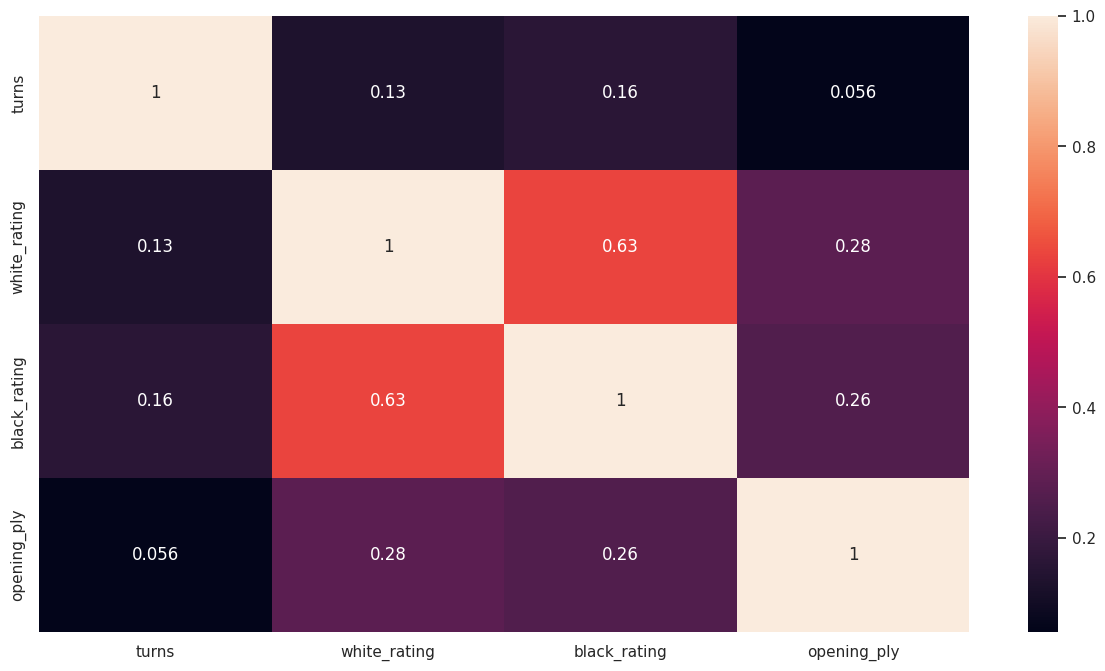

In [ ]:
sns.set()

plt.figure(figsize=(15, 8))

sns.heatmap(chess_corr.corr(numeric_only = True), annot=True)
plt.show()

4. Постройте графики рассеяния по этим признакам
5. Во всех графиках, которые вы cделали: измените цвета,
добавьте заголовки, подпишите оси.


Очищаем датасет от выбросов


In [ ]:
def clean_outliers(df, columns, method):
    for i in columns:
        outliers_2 = outlie(df, i, method)
        df = df.drop(outliers_2.index)
    return df

In [ ]:
clean_chess = clean_outliers(chess, ['turns', 'black_rating', 'white_rating', 'opening_ply'], method='IQR')

<Figure size 1000x1000 with 0 Axes>

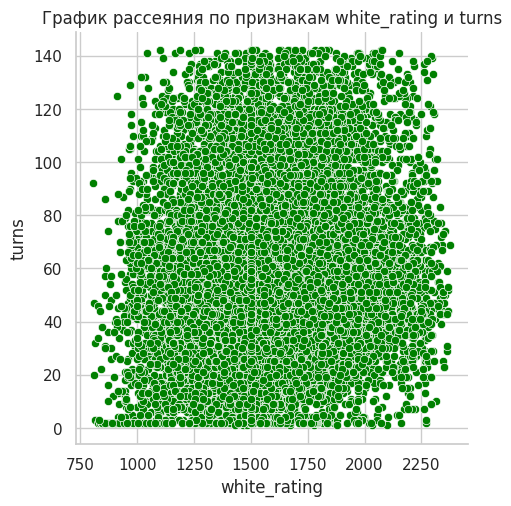

In [ ]:
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.figure(figsize=(10, 10))
sns.relplot(x='white_rating', y='turns', data=clean_chess, color= 'green')
plt.title('График рассеяния по признакам white_rating и turns')
plt.show()

<Figure size 1000x1000 with 0 Axes>

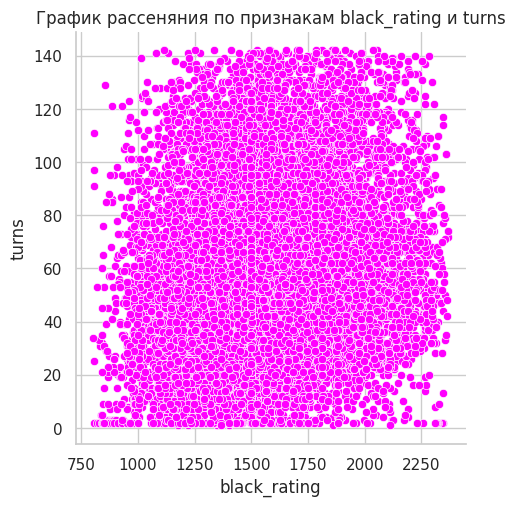

In [ ]:
plt.figure(figsize=(10, 10))
sns.relplot(x='black_rating', y='turns', data=clean_chess, color = 'magenta')
plt.title('График рассеняния по признакам black_rating и turns')
plt.show()

<Figure size 1000x1000 with 0 Axes>

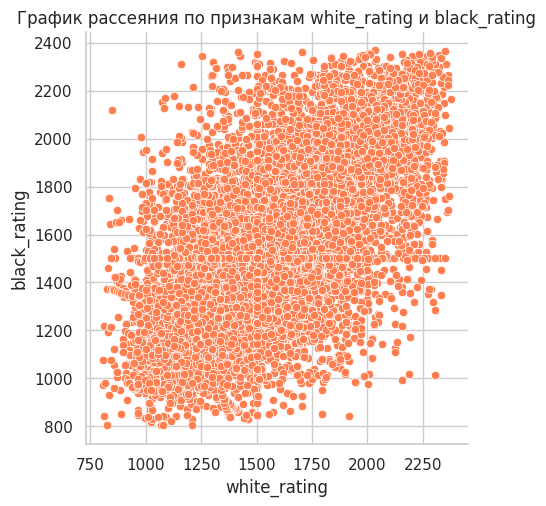

In [ ]:
plt.figure(figsize= (10,10))
sns.relplot(x= 'white_rating', y='black_rating', data = clean_chess, color = 'coral')
plt.title('График рассеяния по признакам white_rating и black_rating')
plt.show()

<Figure size 1000x1000 with 0 Axes>

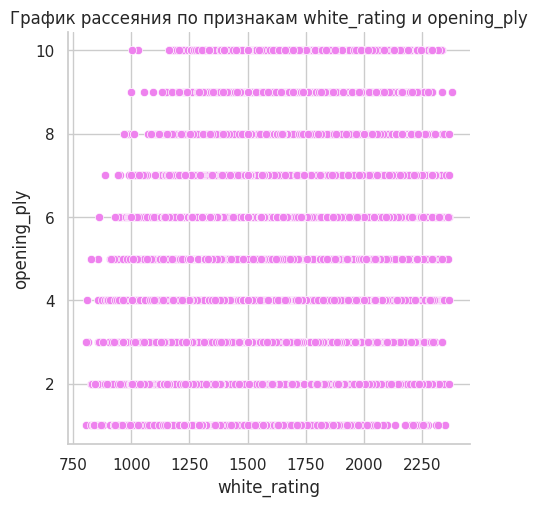

In [ ]:
plt.figure(figsize= (10,10))
sns.relplot(x= 'white_rating', y='opening_ply', data = clean_chess, color = 'violet')
plt.title('График рассеяния по признакам white_rating и opening_ply')
plt.show()

<Figure size 1000x1000 with 0 Axes>

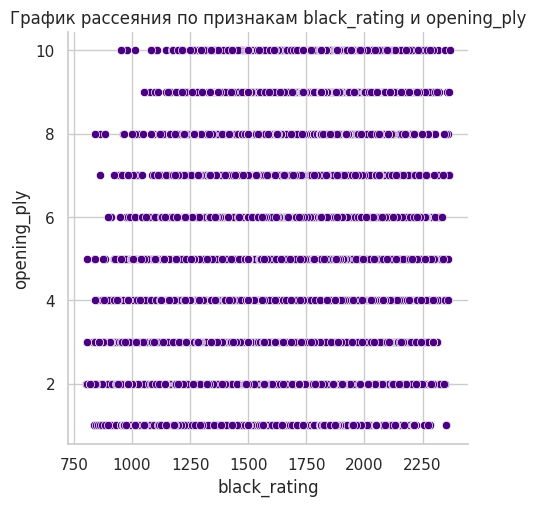

In [ ]:
plt.figure(figsize= (10,10))
sns.relplot(x= 'black_rating', y='opening_ply', data = clean_chess, color = 'indigo')
plt.title('График рассеяния по признакам black_rating и opening_ply')
plt.show()

<Figure size 1000x1000 with 0 Axes>

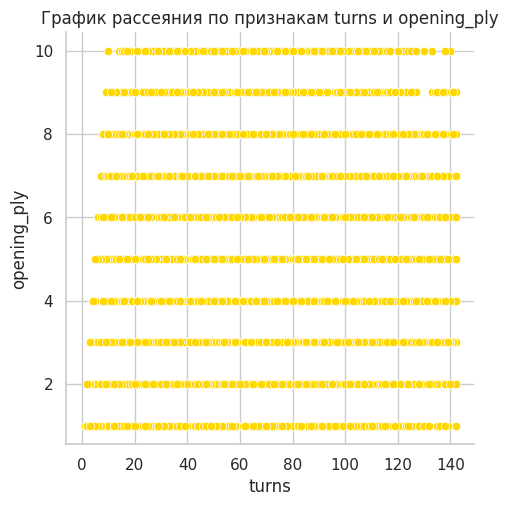

In [ ]:
plt.figure(figsize= (10,10))
sns.relplot(x= 'turns', y='opening_ply', data = clean_chess, color = 'gold')
plt.title('График рассеяния по признакам turns и opening_ply')
plt.show()

6. **Исследовательская гипотеза**

Перед тем, как построить линейную регрессию, мы выдвинули следующую гипотезу:

*Чем выше рейтинг игроков, тем больше ходов они сделают*

Зависимая переменная: turns (количество ходов)
Независимые переменные: white_rating и black_rating



In [ ]:
import statsmodels.api as sm

In [ ]:
X = sm.add_constant(clean_chess[['white_rating','black_rating']])  # предиктор/независимая переменная
Y = clean_chess['turns']                                       # целевая переменная/зависимая переменная
model = sm.OLS(Y, X).fit()                                      # обучаем модель (находим параметры w)

In [ ]:
model.params

,0
const,29.387858
white_rating,0.005468
black_rating,0.012722


В данном случае, мы понимаем, что константа равна примерно 29 (это также можно трактовать как среднее количество ходов во всех партиях).

В таком случае, у переменной white_rating коэффициент равен примерно 0.005. Это положительный эффект, но настолько маленький, что увеличение переменной white_rating на 1 пункт не приведет практически ни к какому результату.

В то время, игрок черными фигурами и переменная black_rating имеют коэффициент 0.01, что практически в два раза больше, чем у white_rating, но коэффициент все еще настолько маленький, что такую корреляцию рассматривать всерьез нельзя.


In [ ]:
model.rsquared

0.024100179185825188

Параметр R-squared у нашей модели находится в естественном диапазоне (0 < R-squared < 1). Однако, несмотря на это, равен всего лишь 0.02, что может означать, что данная модель не дает хороших прогнозов по данным, а также демонстрирует, что, возможно, существуют другие факторы, не включенные в модель, но оказывающие влияние на итоговый результат. Совокупность этих двух аргументов демонстрирует недостаточность эффективности модели. В нашем случае, мы ограничены в выборе данных числовых форматов из-за особенностей выбранного датасета, но низкая эффективность модели по R-squared показывает, что рейтинг игроков практически никак не влияет на количество ходов, сделанное ими за игру. А также обращает наше внимание на то, что на количество ходов наверняка влияют другие факторы.

In [ ]:
Y_pr = model.predict(X)
MSE = sum((Y-Y_pr)**2)/len(Y)
MSE

889.5107254751626

 Mean Squared Error показывает среднюю величину ошибок между предсказанным значением и фактическим значением. В нашем случае этот коэффициент составляет примерно 890, что означает, что выбранная нами модель очень вероятно может допустить ошибки при предсказании результата. Ровно также как и в случае с предыдущим показателем, это означает, что выбранные данные для модели в симбиозе крайне неэффективны, что означает, что существуют другие факторы, не включенные в модель, оказывающие большее влияние на конечный результат. Из этого мы можем еще раз убедиться, что рейтинги игроков белыми и черными практически никак не влияют на количество ходов, которое те сделают за игру. На этот показатель большее влияние оказывают другие факторы.

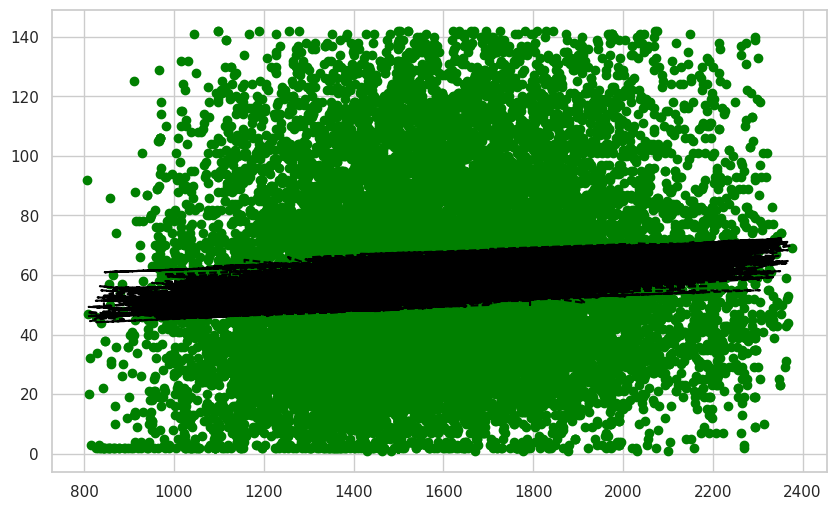

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(clean_chess['white_rating'], Y, color='green', label='white_rating')
plt.plot(clean_chess['white_rating'], model.predict(X), color='black', linestyle='--', label='white_rating regression line')

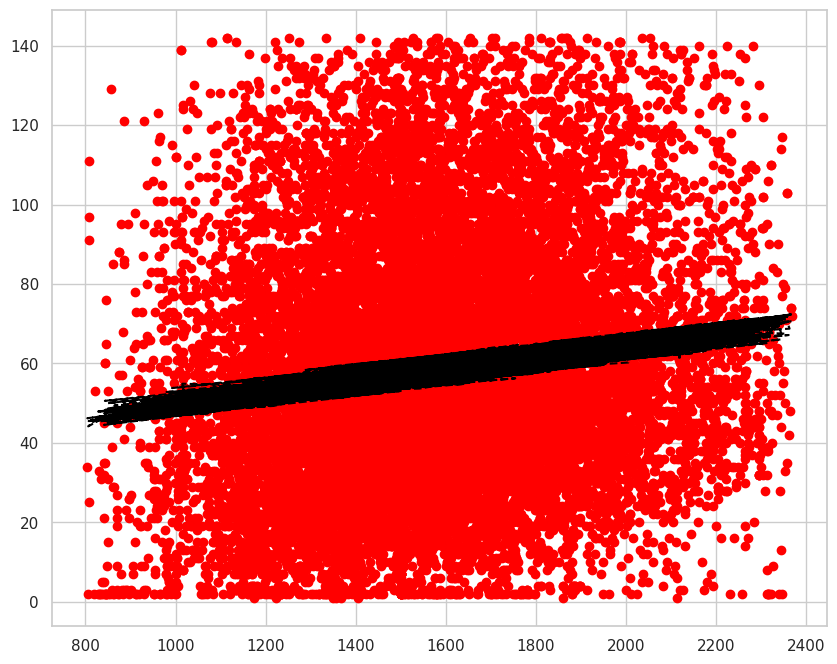

In [ ]:
plt.figure(figsize= (10,))
plt.scatter(clean_chess['black_rating'], Y, color='red', label='black_rating')
plt.plot(clean_chess['black_rating'], model.predict(X), color='black', linestyle='--', label='black_rating regression line')

Выводом нашего исследования посредством построения линейной регрессии и выявления основных параметров модели становится опровержение выдвинутой нами ранее гипотезы:

*Чем выше рейтинг игроков, тем больше ходов они сделают*

Наше исследование показало, что параметры модели построенной с использованием переменных, отвечающих нашей гипотезы, далеки от идеала. Их положение абсолютно естественно, из чего следует, что сам факт предположения подобной гипотезы не ошибочен, однако показатели этих параметров опровергают наше утверждение о том, что рейтинг игроков каждого цвета влияет на количество ходов, которе игроки суммарно сделают за всю игру.

Для того, чтобы выявить, от чего на самом деле зависит количество ходов, необходимо строить корреляции, включающие в себя другие параметры.

**Вывод: наша гипотеза была ошибочна, рейтинг игроков НЕ влияет на количество ходов в игре**